In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Load the engineered data
df = pd.read_csv('../../data/engineered_earthquake_data.csv')

# 2. Setup Target & Features
threshold = df['magnitude'].median()
df['High_Risk'] = (df['magnitude'] >= threshold).astype(int)

X = df[['depth_scaled', 'latitude', 'longitude', 'location_risk_score']]
y = df['High_Risk']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train our Best Model (Random Forest)
print("Training the final model for evaluation...")
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# 5. Make final predictions
preds = best_model.predict(X_test)
print("Model trained and predictions generated! Ready for evaluation.")

Training the final model for evaluation...
Model trained and predictions generated! Ready for evaluation.


--- Classification Metrics ---
              precision    recall  f1-score   support

           0       0.62      0.46      0.53        78
           1       0.58      0.72      0.64        79

    accuracy                           0.59       157
   macro avg       0.60      0.59      0.58       157
weighted avg       0.60      0.59      0.59       157



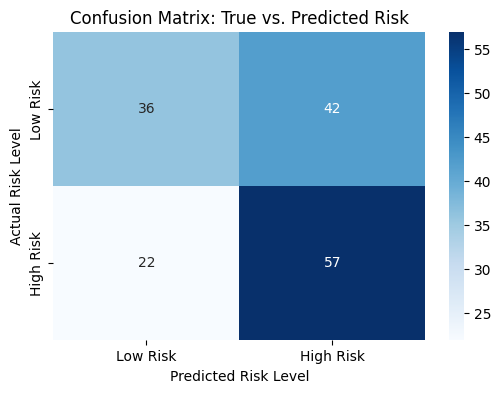

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Print detailed metrics (Accuracy, Precision, Recall, F1-Score)
print("--- Classification Metrics ---")
print(classification_report(y_test, preds))

# 2. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk', 'High Risk'], 
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix: True vs. Predicted Risk')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_23924\2019399292.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='magma')


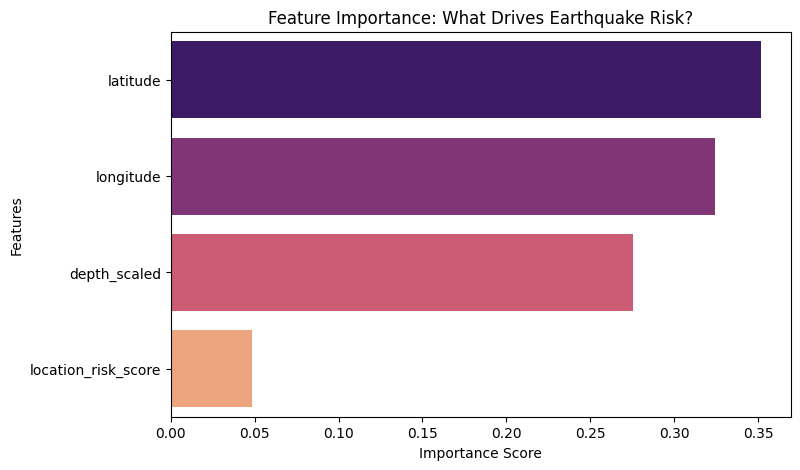

In [8]:
import numpy as np

# 1. Extract feature importances from the model
importances = best_model.feature_importances_
features = X.columns

# 2. Sort them from most important to least important
indices = np.argsort(importances)[::-1]

# 3. Plot the Feature Importance Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features[indices], palette='magma')
plt.title('Feature Importance: What Drives Earthquake Risk?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Calculating SHAP values... (This takes a moment)


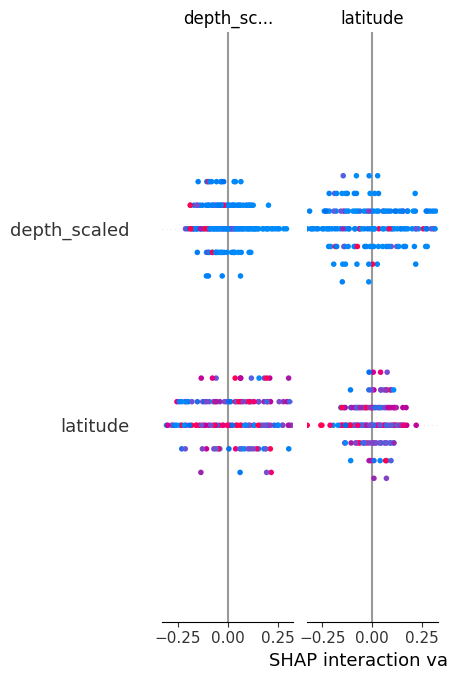

In [9]:
import shap

print("Calculating SHAP values... (This takes a moment)")

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# 2. Calculate SHAP values
# We use a sample of 500 rows to prevent the notebook from freezing, just like we did with the map!
X_test_sample = X_test.sample(n=500, random_state=42) if len(X_test) > 500 else X_test
shap_values = explainer.shap_values(X_test_sample)

# 3. Plot the SHAP Summary
# For Random Forest classification, shap_values is a list. We plot index 1 to see the impact on 'High Risk'
shap_to_plot = shap_values[:, :, 1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(shap_to_plot, X_test_sample)

Training a quick Regression model to evaluate MAE/MSE...
Mean Absolute Error (MAE): 0.3521
Mean Squared Error (MSE): 0.2064


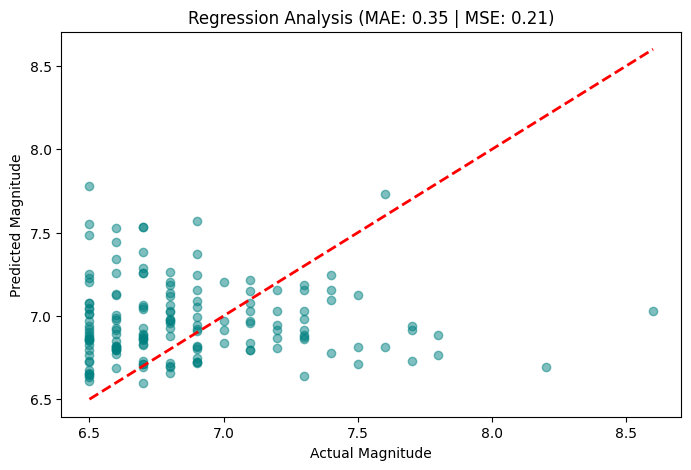

In [11]:
# Cell 5: Regression Evaluation (MAE & MSE Plots)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Training a quick Regression model to evaluate MAE/MSE...")

# 1. Setup for Regression: We will predict the exact 'magnitude' this time
y_reg = df['magnitude']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 2. Train a Regression Model
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)
reg_preds = reg_model.predict(X_test_reg)

# 3. Calculate MAE and MSE
mae = mean_absolute_error(y_test_reg, reg_preds)
mse = mean_squared_error(y_test_reg, reg_preds)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# 4. Plot Actual vs Predicted (Visualizing the Error)
plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, reg_preds, alpha=0.5, color='teal')
# Draw the line of perfect prediction
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title(f'Regression Analysis (MAE: {mae:.2f} | MSE: {mse:.2f})')
plt.show()

In [10]:
# Cell 5: Export the Model for the Web App
import joblib
import os

# Create a 'models' folder if it doesn't exist yet
os.makedirs('../models', exist_ok=True)

# Save the model as a .pkl file
joblib.dump(best_model, '../models/earthquake_model.pkl')
print("Model successfully saved to the 'models' folder!")

Model successfully saved to the 'models' folder!
